In [2]:
# Check if using GPU
import tensorflow as tf
if tf.test.gpu_device_name() == '/device:GPU:0':
  print("GPU is active")
else:
  print("GPU is not active")

GPU is active


In [1]:
#@title Default title text
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [2]:
!pip install whitebox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 2.8 MB/s eta 0:00:00


In [3]:
!pip install whitebox-workflows

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 21.9 MB/s eta 0:00:00


In [4]:
!pip install geemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.9 MB/s eta 0:00:00


In [5]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 38.2 MB/s eta 0:00:00


In [6]:
# Install rioxarry
!pip install rioxarray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 3.7 MB/s eta 0:00:00


In [7]:
!pip install earthpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 20.6 MB/s eta 0:00:00


In [8]:
pip install earthpy rasterio matplotlib

In [9]:
import whitebox
import whitebox_workflows as wbw
import geemap
import rioxarray as rxr
import rasterio
import earthpy as et
import earthpy.plot as ep
import matplotlib.pyplot as plt
import geopandas as gpd
from rasterio.plot import plotting_extent

In [10]:
wbt = whitebox.WhiteboxTools()

Decompressing WhiteboxTools_linux_musl.zip ...
WhiteboxTools package directory: /usr/local/lib/python3.10/dist-packages/whitebox


In [13]:
wbt.lidar_info(
    i="/content/drive/MyDrive/Doktora/TBC/ground-off-ground.las",
    output="/content/drive/MyDrive/Doktora/TBC/wb_data_las_info.html"
)

./whitebox_tools --run="LidarInfo" --input='/content/drive/MyDrive/Doktora/TBC/ground-off-ground.las' --output='/content/drive/MyDrive/Doktora/TBC/wb_data_las_info.pdf' --density --vlr --geokeys -v --compress_rasters=False

****************************
* Welcome to LidarInfo     *
* Powered by WhiteboxTools *
* www.whiteboxgeo.com      *
****************************
Complete! Please see /content/drive/MyDrive/Doktora/TBC/wb_data_las_info.pdf for output.


0

In [12]:
wbt.lidar_histogram(
    i="/content/drive/MyDrive/Doktora/TBC/ground-off-ground.las",
    output="/content/drive/MyDrive/Doktora/TBC/wb_data_class_hist.html",
    parameter="CLASS",
    clip=0
)

./whitebox_tools --run="LidarHistogram" --input='/content/drive/MyDrive/Doktora/TBC/ground-off-ground.las' --output='/content/drive/MyDrive/Doktora/TBC/wb_data_class_hist.html' --parameter=CLASS --clip=0 -v --compress_rasters=False

*****************************
* Welcome to LidarHistogram *
* Powered by WhiteboxTools  *
* www.whiteboxgeo.com       *
*****************************
reading input LiDAR file...
Calculating min and max: 0%
Calculating min and max: 1%
Calculating min and max: 2%
Calculating min and max: 3%
Calculating min and max: 4%
Calculating min and max: 5%
Calculating min and max: 6%
Calculating min and max: 7%
Calculating min and max: 8%
Calculating min and max: 9%
Calculating min and max: 10%
Calculating min and max: 11%
Calculating min and max: 12%
Calculating min and max: 13%
Calculating min and max: 14%
Calculating min and max: 15%
Calculating min and max: 16%
Calculating min and max: 17%
Calculating min and max: 18%
Calculating min and max: 19%
Calculating min and

0

In [22]:
wbt.lidar_idw_interpolation(
    i="/content/drive/MyDrive/Doktora/TBC/ground-off-ground.las",
    output="/content/drive/MyDrive/Doktora/TBC/idw_dtm1.tif",
    parameter="ELEVATION",
    resolution=0.3,
    exclude_cls="5, 6",
)

./whitebox_tools --run="LidarIdwInterpolation" --input='/content/drive/MyDrive/Doktora/TBC/ground-off-ground.las' --output='/content/drive/MyDrive/Doktora/TBC/idw_dtm1.tif' --parameter=ELEVATION --returns=all --resolution=0.3 --weight=1.0 --radius=2.5 --exclude_cls='5, 6' -v --compress_rasters=False

************************************
* Welcome to LidarIdwInterpolation *
* Powered by WhiteboxTools         *
* www.whiteboxgeo.com              *
************************************
Performing interpolation...
reading input LiDAR file...
Binning points: 0%
Binning points: 1%
Binning points: 2%
Binning points: 3%
Binning points: 4%
Binning points: 5%
Binning points: 6%
Binning points: 7%
Binning points: 8%
Binning points: 9%
Binning points: 10%
Binning points: 11%
Binning points: 12%
Binning points: 13%
Binning points: 14%
Binning points: 15%
Binning points: 16%
Binning points: 17%
Binning points: 18%
Binning points: 19%
Binning points: 20%
Binning points: 21%
Binning points: 22%
Binning

0

In [11]:
geemap.add_crs("/content/drive/MyDrive/Doktora/TBC/idw_dtm1.tif",
               epsg=5258)
idw_dtm = rxr.open_rasterio("/content/drive/MyDrive/Doktora/TBC/idw_dtm1.tif",
                            masked=True)


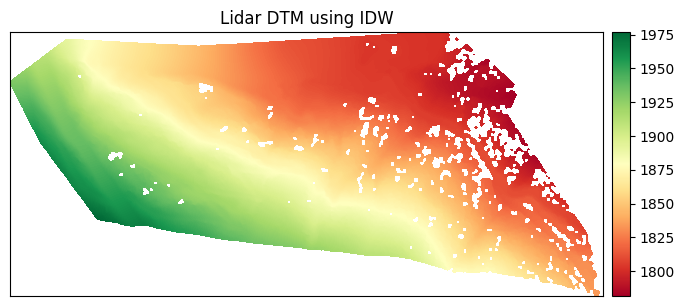

In [12]:
ep.plot_bands(
    arr=idw_dtm,
    cmap="RdYlGn",
    figsize=(8, 8),
    title="Lidar DTM using IDW"
)

plt.show()

In [13]:
wbt.lidar_tin_gridding(
    i="/content/drive/MyDrive/Doktora/TBC/ground-off-ground.las",
    output="/content/drive/MyDrive/Doktora/TBC/tin_dtm.tif",
    parameter="ELEVATION",
    resolution=0.3,
    exclude_cls="5, 6",
    max_triangle_edge_length=5
)

./whitebox_tools --run="LidarTinGridding" --input='/content/drive/MyDrive/Doktora/TBC/ground-off-ground.las' --output='/content/drive/MyDrive/Doktora/TBC/tin_dtm.tif' --parameter=ELEVATION --returns=all --resolution=0.3 --exclude_cls=5, 6 --max_triangle_edge_length='5' -v --compress_rasters=False

*******************************
* Welcome to LidarTINGridding *
* Powered by WhiteboxTools    *
* www.whiteboxgeo.com         *
*******************************
Performing interpolation...
Reading input LiDAR file...
Reading points: 0%
Reading points: 1%
Reading points: 2%
Reading points: 3%
Reading points: 4%
Reading points: 5%
Reading points: 6%
Reading points: 7%
Reading points: 8%
Reading points: 9%
Reading points: 10%
Reading points: 11%
Reading points: 12%
Reading points: 13%
Reading points: 14%
Reading points: 15%
Reading points: 16%
Reading points: 17%
Reading points: 18%
Reading points: 19%
Reading points: 20%
Reading points: 21%
Reading points: 22%
Reading points: 23%
Reading points:

0

In [14]:
geemap.add_crs("/content/drive/MyDrive/Doktora/tin_dtm.tif",
               epsg=5258)

tin_dtm = rxr.open_rasterio("/content/drive/MyDrive/Doktora/tin_dtm.tif",
                            masked=True)

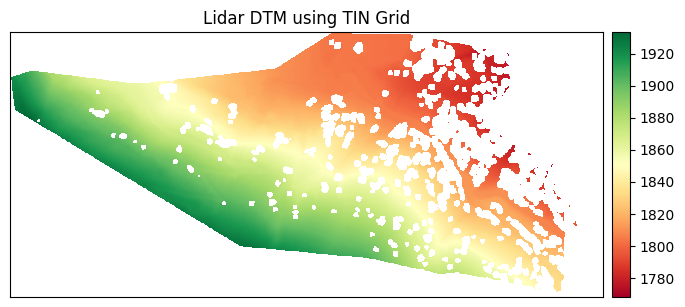

In [15]:
# View the raster
ep.plot_bands(
    arr=tin_dtm,
    cmap="RdYlGn",
    figsize=(8, 8),
    title="Lidar DTM using TIN Grid"
)

plt.show();


In [ ]:
# Fill missing data
wbt.fill_missing_data(
    i="/content/drive/MyDrive/Doktora/tin_dtm.tif",
    output="/content/drive/MyDrive/Doktora/tin_dtm_filled.tif",
    filter=19,
    weight=2,
    no_edges=False,
)

./whitebox_tools --run="FillMissingData" --input='/content/drive/MyDrive/Doktora/tin_dtm.tif' --output='/content/drive/MyDrive/Doktora/tin_dtm_filled.tif' --filter=19 --weight=2 -v --compress_rasters=False

******************************
* Welcome to FillMissingData *
* Powered by WhiteboxTools   *
* www.whiteboxgeo.com        *
******************************
Reading data...
Interpolating data holes...
Interpolating data holes: 0%
Interpolating data holes: 1%
Interpolating data holes: 2%
Interpolating data holes: 3%
Interpolating data holes: 4%
Interpolating data holes: 5%
Interpolating data holes: 6%
Interpolating data holes: 7%
Interpolating data holes: 8%
Interpolating data holes: 9%
Interpolating data holes: 10%
Interpolating data holes: 11%
Interpolating data holes: 12%
Interpolating data holes: 13%
Interpolating data holes: 14%
Interpolating data holes: 15%
Interpolating data holes: 16%
Interpolating data holes: 17%
Interpolating data holes: 18%
Interpolating data holes: 19%
Inte

0

In [ ]:
geemap.add_crs("/content/drive/MyDrive/Doktora/tin_dtm_filled.tif",
               epsg=5258)

tin_dtm_filled = rxr.open_rasterio("/content/drive/MyDrive/Doktora/tin_dtm_filled.tif",
                            masked=True)

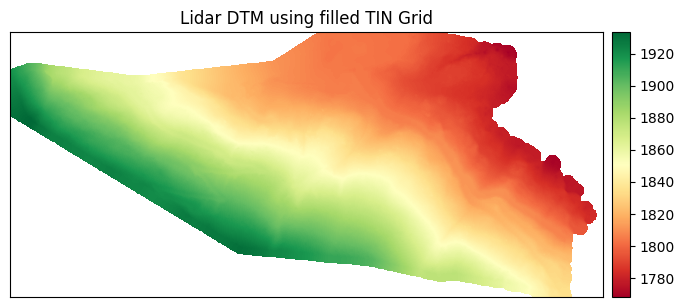

In [ ]:
# View the raster
ep.plot_bands(
    arr=tin_dtm_filled,
    cmap="RdYlGn",
    figsize=(8, 8),
    title="Lidar DTM using filled TIN Grid",

)

plt.show();

In [ ]:
# Fill missing data
wbt.fill_missing_data(
    i="/content/drive/MyDrive/Doktora/idw_dtm.tif",
    output="/content/drive/MyDrive/Doktora/idw_dtm_filled.tif",
    filter=12,
    weight=2,
    no_edges=False,
)

./whitebox_tools --run="FillMissingData" --input='/content/drive/MyDrive/Doktora/idw_dtm.tif' --output='/content/drive/MyDrive/Doktora/idw_dtm_filled.tif' --filter=12 --weight=2 -v --compress_rasters=False

******************************
* Welcome to FillMissingData *
* Powered by WhiteboxTools   *
* www.whiteboxgeo.com        *
******************************
Reading data...
Interpolating data holes...
Interpolating data holes: 0%
Interpolating data holes: 1%
Interpolating data holes: 2%
Interpolating data holes: 3%
Interpolating data holes: 4%
Interpolating data holes: 5%
Interpolating data holes: 6%
Interpolating data holes: 7%
Interpolating data holes: 8%
Interpolating data holes: 9%
Interpolating data holes: 10%
Interpolating data holes: 11%
Interpolating data holes: 12%
Interpolating data holes: 13%
Interpolating data holes: 14%
Interpolating data holes: 15%
Interpolating data holes: 16%
Interpolating data holes: 17%
Interpolating data holes: 18%
Interpolating data holes: 19%
Inte

0

In [ ]:
geemap.add_crs("/content/drive/MyDrive/Doktora/idw_dtm_filled.tif",
               epsg=5258)

idw_dtm_filled = rxr.open_rasterio("/content/drive/MyDrive/Doktora/idw_dtm_filled.tif",
                            masked=True)

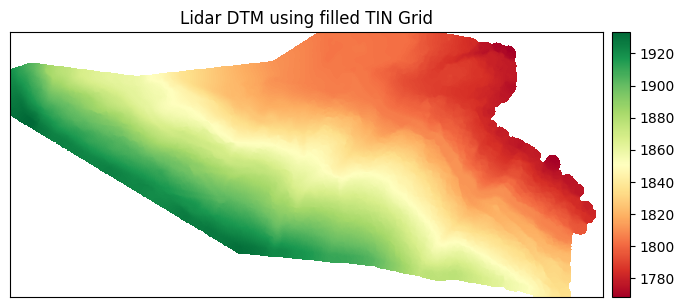

In [ ]:
# View the raster
ep.plot_bands(
    arr=idw_dtm_filled,
    cmap="RdYlGn",
    figsize=(8, 8),
    title="Lidar DTM using filled TIN Grid"
)

plt.show();

In [ ]:
# Create the DSM
wbt.lidar_digital_surface_model(
    i="/content/drive/MyDrive/Doktora/normalized_vegetation_R.las",
    output="/content/drive/MyDrive/Doktora/nrm_vgt_idw.tif",
    resolution=0.5,
    radius=2.5, # Same as for IDW interpolation
    #max_triangle_edge_length=5 # Same as for TIN Gridding. Leaving it as None will create triangles at the edge
)

./whitebox_tools --run="LidarDigitalSurfaceModel" --input='/content/drive/MyDrive/Doktora/normalized_vegetation_R.las' --output='/content/drive/MyDrive/Doktora/nrm_vgt_idw.tif' --resolution=0.5 --radius=2.5 -v --compress_rasters=False

***************************************
* Welcome to LidarDigitalSurfaceModel *
* Powered by WhiteboxTools            *
* www.whiteboxgeo.com                 *
***************************************
Performing interpolation...
Reading input LiDAR file...
Reading points: 0%
Reading points: 1%
Reading points: 2%
Reading points: 3%
Reading points: 4%
Reading points: 5%
Reading points: 6%
Reading points: 7%
Reading points: 8%
Reading points: 9%
Reading points: 10%
Reading points: 11%
Reading points: 12%
Reading points: 13%
Reading points: 14%
Reading points: 15%
Reading points: 16%
Reading points: 17%
Reading points: 18%
Reading points: 19%
Reading points: 20%
Reading points: 21%
Reading points: 22%
Reading points: 23%
Reading points: 24%
Reading points: 25

0